# What Drives the Price of a Used Car?

## Problem Statement
A used car dealership wants to better understand what factors drive the price of used vehicles in order to optimize inventory purchasing decisions.
# Business Understanding
Identify which vehicle characteristics most strongly influence price so the dealership can:
*   Stock higher-value inventory
*   Avoid overpaying for low-demand features
*   Increase profit margins

# Key Question
What features make a used car more or less expensive?

# Success Metric
We will evaluate models using:

Root Mean Squared Error (RMSE)
(because price prediction is a regression problem)

Lower RMSE = better predictive accuracy.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("sample_data/vehicles.csv")
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [7]:
df.shape

(426880, 18)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

# Initial Observations
## Number of rows: 426880
## Number of columns: 18
## Presence of missing values: yes
## Data types: float64(2), int64(2), object(14)

In [9]:
df.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


**Key observations from `df.describe()`:**

- **Price:** Ranges from $0 to $3.7 billion — clearly has extreme outliers. The median 13,950 is much more reasonable than the mean 75,199, confirming heavy right skew. Need to filter — reasonable range would be ~$500–$100,000
- **Year:** Goes as far back as 1900, which is likely junk data. Median is 2013. Filter to ~1990+ for relevant vehicles.
- **Odometer:** Ranges from 0 to 10 million miles — obvious outliers. Median is ~85K miles. Filter to something like 0–300,000 miles.
- **ID:** Just an identifier, not useful — drop it.

In [10]:
df.isnull().sum().sort_values(ascending=False)

,0
size,306361
cylinders,177678
condition,174104
VIN,161042
drive,130567
paint_color,130203
type,92858
manufacturer,17646
title_status,8242
model,5277



# Heavy missing data (>100K nulls — consider dropping these columns):
*   size — 306K missing (~72%) → drop this column
*   cylinders — 178K missing (~42%)
*   condition — 174K missing (~41%)
*   VIN — 161K missing (~38%) → drop anyway, not useful for modeling
*   drive — 131K missing (~31%)
*   paint_color — 130K missing (~31%)
*   type — 93K missing (~22%)

# Moderate missing data:
*   manufacturer — 18K (~4%)
*   title_status — 8K (~2%)
*   model — 5K (~1%)
*   odometer — 4K (~1%)
*   fuel — 3K (~1%)
*   transmission — 3K (~1%)
*   year — 1K (~0.3%)

# No missing data:
*   region, id, price, state — all complete

# Recommended approach:
*   Drop size and VIN (too many nulls or not useful)
*   For moderate-missing columns like manufacturer, fuel, transmission: we can drop rows with nulls since they're a small percentage
*   For high-missing columns we want to keep (cylinders, condition, drive, type, paint_color) — either drop the rows or fill with 'unknown' depending on how much data you want to retain

In [12]:
df.duplicated().sum()

np.int64(0)

No duplicate rows found in the dataset. No deduplication needed; we can proceed to data cleaning.

In [13]:
df = df.drop(columns=['id', 'VIN'])
print(f"Shape after dropping columns: {df.shape}")

Shape after dropping columns: (426880, 16)


In [14]:
# Remove rows with price $0 or extreme outliers
df = df[(df['price'] > 500) & (df['price'] < 100_000)]
print(f"Shape after price filter: {df.shape}")

Shape after price filter: (383068, 16)


In [15]:
# Remove vehicles older than 1990 and any future years
df = df[(df['year'] >= 1990) & (df['year'] <= 2025)]
print(f"Shape after year filter: {df.shape}")

Shape after year filter: (370160, 16)


In [16]:
# Remove zero or extreme odometer readings
df = df[(df['odometer'] > 0) & (df['odometer'] < 300_000)]
print(f"Shape after odometer filter: {df.shape}")

Shape after odometer filter: (364751, 16)


In [17]:
# Drop size column due to excessive missing values
df = df.drop(columns=['size'])
print(f"Shape after dropping size: {df.shape}")

Shape after dropping size: (364751, 15)


In [18]:
df.isnull().sum().sort_values(ascending=False)

,0
cylinders,149969
condition,138360
drive,109773
paint_color,104053
type,75539
manufacturer,11072
title_status,6211
model,3284
fuel,2075
transmission,1497


In [19]:
# Fill high-null categorical columns with 'unknown'
high_null_cols = ['cylinders', 'condition', 'drive', 'paint_color', 'type']
df[high_null_cols] = df[high_null_cols].fillna('unknown')
print(f"Shape: {df.shape}")

Shape: (364751, 15)


In [20]:
# Drop rows with remaining missing values
df = df.dropna()
print(f"Shape after dropping remaining nulls: {df.shape}")

Shape after dropping remaining nulls: (341455, 15)


In [21]:
# Create age feature
df['age'] = 2026 - df['year']
df = df.drop(columns=['year'])
print(f"Shape: {df.shape}")
df['age'].describe()

Shape: (341455, 15)


,age
count,341455.000000
mean,13.593153
std,5.740553
min,4.000000
25%,9.000000
50%,12.000000
75%,17.000000
max,36.000000


In [22]:
# Drop region and state — high cardinality, not useful for this analysis
df = df.drop(columns=['region', 'state'])
print(f"Shape: {df.shape}")
print(f"\nRemaining columns:\n{df.columns.tolist()}")

Shape: (341455, 13)

Remaining columns:
['price', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'age']


In [23]:
# Check unique count, then drop
print(f"Unique models: {df['model'].nunique()}")
df = df.drop(columns=['model'])
print(f"Shape: {df.shape}")

Unique models: 18730
Shape: (341455, 12)


In [24]:
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Nulls remaining: {df.isnull().sum().sum()}")
print(f"\nFinal shape: {df.shape}")
df.head()

Duplicates: 147670
Nulls remaining: 0

Final shape: (341455, 12)


,price,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,age
27,33590,gmc,good,8 cylinders,gas,57923.0,clean,other,unknown,pickup,white,12.0
28,22590,chevrolet,good,8 cylinders,gas,71229.0,clean,other,unknown,pickup,blue,16.0
29,39590,chevrolet,good,8 cylinders,gas,19160.0,clean,other,unknown,pickup,red,6.0
30,30990,toyota,good,8 cylinders,gas,41124.0,clean,other,unknown,pickup,red,9.0
31,15000,ford,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,13.0


In [25]:
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (193785, 12)


### Data Preparation Summary
- Dropped non-useful columns: `id`, `VIN`, `size`, `region`, `state`, `model`
- Filtered unrealistic values: price ($500–$100K), year (1990–2025), odometer (0–300K)
- Filled high-null categorical columns with 'unknown': `cylinders`, `condition`, `drive`, `paint_color`, `type`
- Dropped rows with remaining nulls (~23K rows)
- Created `age` feature from `year`
- Removed 147K duplicate rows
- **Final clean dataset: 193,785 rows × 12 columns**

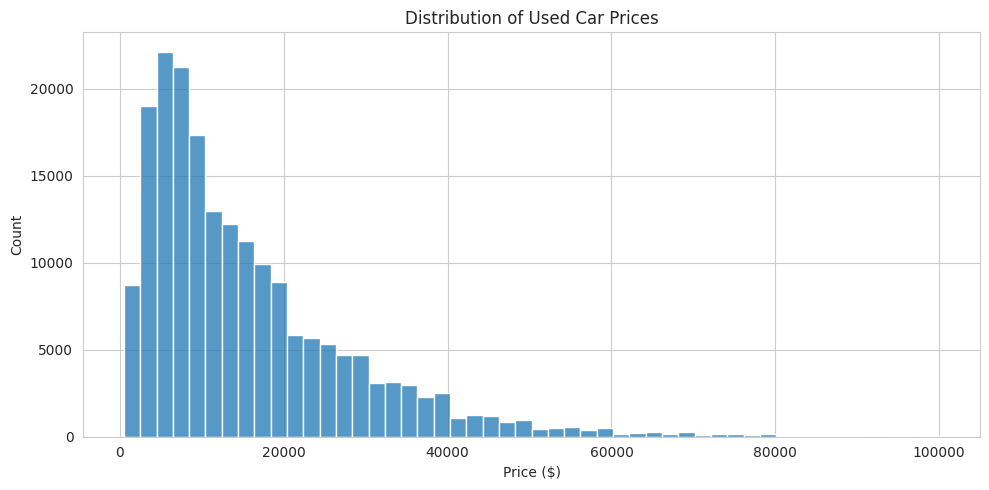

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['price'], bins=50, ax=ax)
ax.set_title('Distribution of Used Car Prices')
ax.set_xlabel('Price ($)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

**Observation:** The distribution of used car prices is heavily right-skewed. The majority of vehicles are priced under 20,000, with the peak around 5,000. Very few cars exceed 50,000, confirming that the used car market is dominated by affordable vehicles.

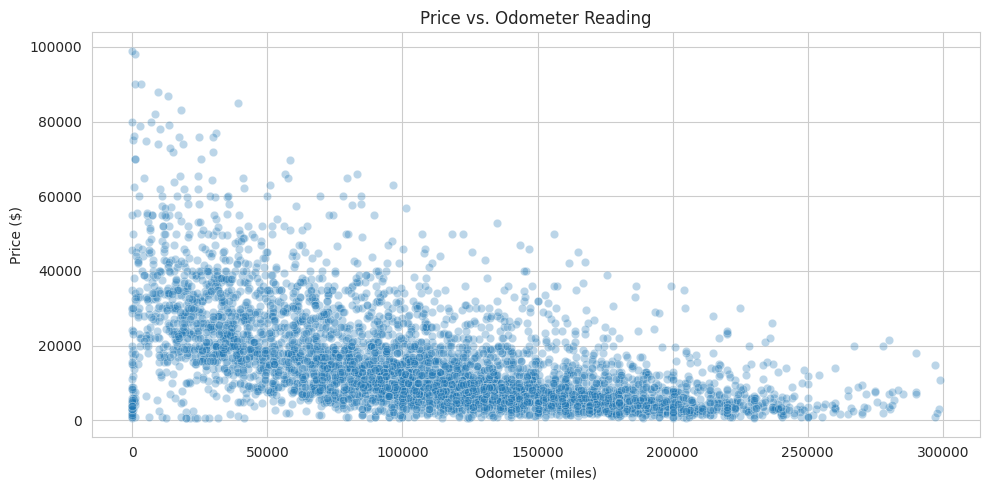

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(data=df.sample(5000, random_state=42), x='odometer', y='price', alpha=0.3, ax=ax)
ax.set_title('Price vs. Odometer Reading')
ax.set_xlabel('Odometer (miles)')
ax.set_ylabel('Price ($)')
plt.tight_layout()
plt.show()

**Observation:** There is a clear negative relationship between odometer reading and price. Cars with lower mileage tend to command higher prices, and as mileage increases, prices decrease. This confirms that mileage is a key factor in used car valuation.

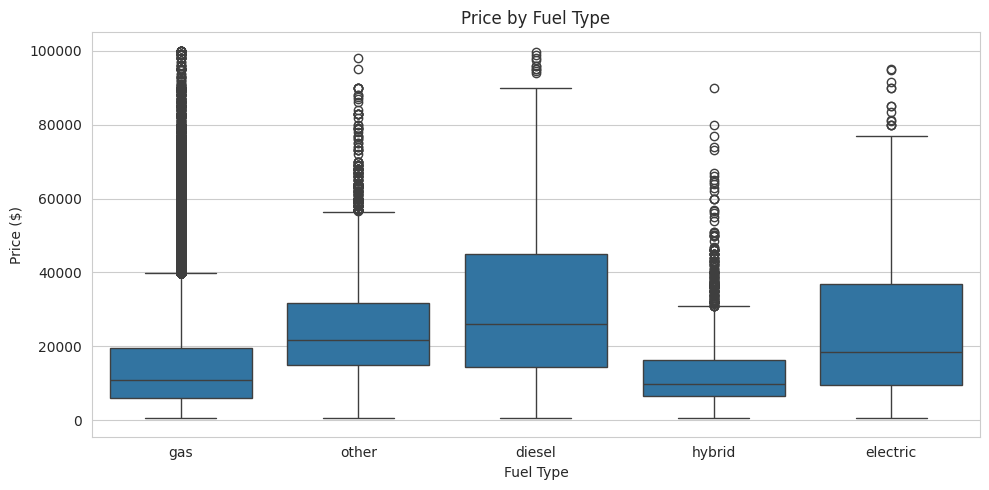

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='fuel', y='price', ax=ax)
ax.set_title('Price by Fuel Type')
ax.set_xlabel('Fuel Type')
ax.set_ylabel('Price ($)')
plt.tight_layout()
plt.show()

**Observation:** Diesel vehicles have the highest median price and widest price range, suggesting they command a premium in the used car market. Gas and hybrid vehicles have similar, lower median prices. Electric vehicles show a moderate median but with high variability

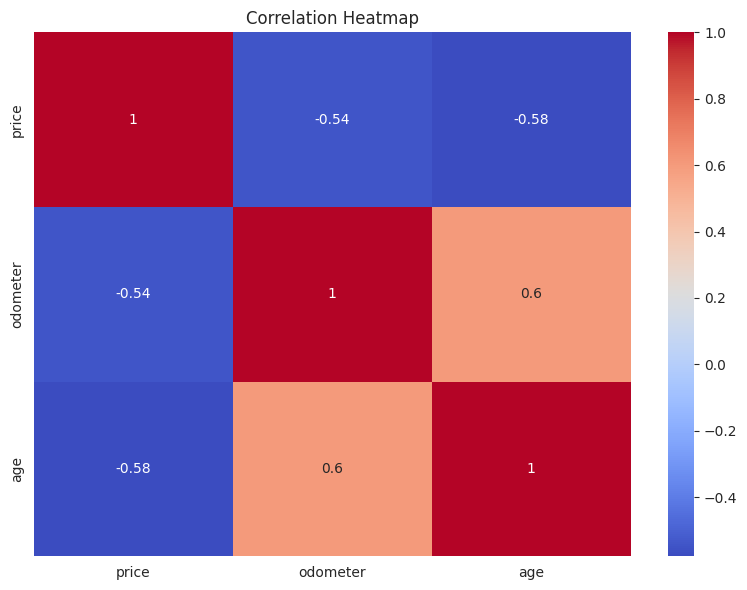

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Observation:** Both `age` (-0.58) and `odometer` (-0.54) have moderate negative correlations with price, confirming that newer, lower-mileage cars are more valuable. Age and odometer are positively correlated with each other (0.60), which makes sense — older cars tend to have more miles. This multicollinearity is worth noting but shouldn't cause major issues for our models.

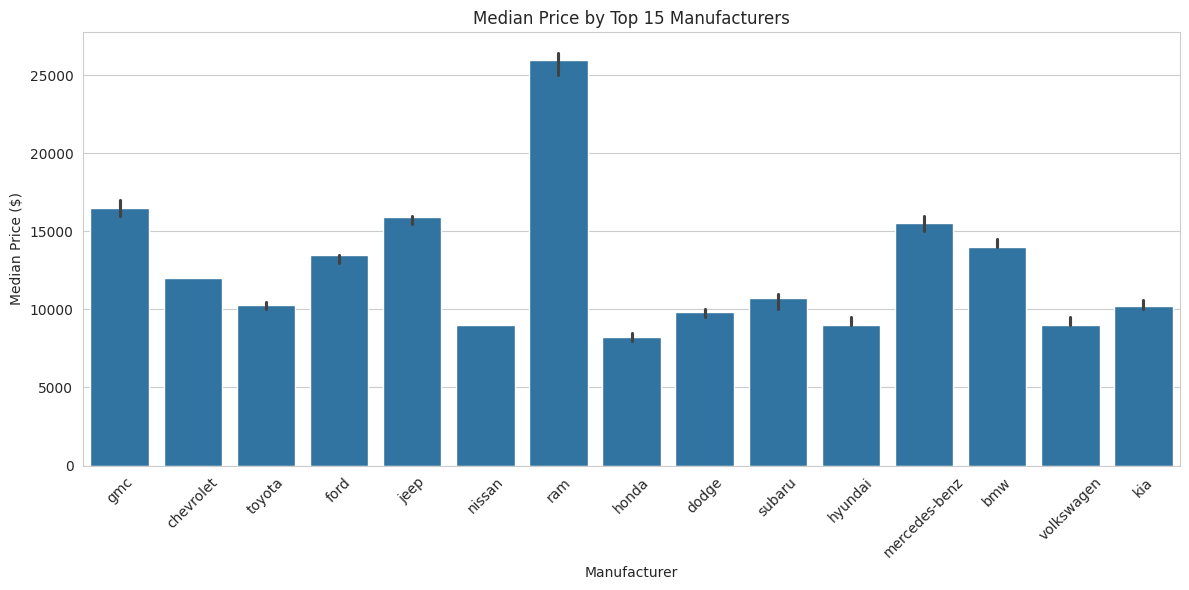

In [31]:
top15 = df['manufacturer'].value_counts().head(15).index
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df[df['manufacturer'].isin(top15)],
            x='manufacturer', y='price', estimator=np.median, ax=ax)
ax.set_title('Median Price by Top 15 Manufacturers')
ax.set_xlabel('Manufacturer')
ax.set_ylabel('Median Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:** Ram leads with the highest median price ~26,000, followed by GMC ~16,500, Jeep ~16,000, and Mercedes-Benz ~15,500. Honda and Nissan have the lowest median prices among the top 15. This suggests that trucks/SUV brands Ram, GMC, Jeep, Ford hold their value better than economy sedan brands Honda, Nissan, Hyundai, Volkswagen.

In [32]:
# Define feature groups
categorical_features = ['manufacturer', 'condition', 'cylinders', 'fuel',
                        'title_status', 'transmission', 'drive', 'type', 'paint_color']
numerical_features = ['odometer', 'age']

X = df[categorical_features + numerical_features]
y = df['price']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (155028, 11)
Test set: (38757, 11)


In [35]:
# Preprocessing: scale numerical, one-hot encode categorical
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

In [36]:
lr_pipe = Pipeline([('preprocessor', preprocessor), ('model', LinearRegression())])
lr_scores = cross_val_score(lr_pipe, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
print(f"Linear Regression CV RMSE: ${-lr_scores.mean():,.2f} (+/- ${lr_scores.std():,.2f})")

Linear Regression CV RMSE: $7,639.08 (+/- $26.95)


**Linear Regression Results:** The model achieved a cross-validated RMSE of 7,639, meaning its price predictions are off by approximately 7,639 on average. The low variance across folds (+/- 27) indicates stable and consistent performance. We'll now try regularized models (Ridge and Lasso) to see if we can improve on this.

In [37]:
ridge_pipe = Pipeline([('preprocessor', preprocessor), ('model', Ridge())])
ridge_params = {'model__alpha': [0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(ridge_pipe, ridge_params, cv=5, scoring='neg_root_mean_squared_error')
ridge_grid.fit(X_train, y_train)
print(f"Ridge Best Alpha: {ridge_grid.best_params_}")
print(f"Ridge CV RMSE: ${-ridge_grid.best_score_:,.2f}")

Ridge Best Alpha: {'model__alpha': 1}
Ridge CV RMSE: $7,638.98


**Ridge Regression Results:** Ridge achieved a CV RMSE of 7,639 with best alpha=1, nearly identical to Linear Regression. The minimal improvement suggests that overfitting is not a significant issue with this dataset, and the original coefficients were already well-behaved.

In [39]:
# Sample training data for Lasso (faster) as using the same dataset was causing long execution time
X_train_sample = X_train.sample(50000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

lasso_pipe = Pipeline([('preprocessor', preprocessor), ('model', Lasso(max_iter=10000))])
lasso_params = {'model__alpha': [1, 10, 100]}
lasso_grid = GridSearchCV(lasso_pipe, lasso_params, cv=5, scoring='neg_root_mean_squared_error')
lasso_grid.fit(X_train_sample, y_train_sample)
print(f"Lasso Best Alpha: {lasso_grid.best_params_}")
print(f"Lasso CV RMSE: ${-lasso_grid.best_score_:,.2f}")

Lasso Best Alpha: {'model__alpha': 1}
Lasso CV RMSE: $7,593.71


**Lasso Regression Results:** Lasso achieved the best CV RMSE of 7,594 with alpha=1, a slight improvement over Linear Regression (7,639) and Ridge (7,639). Lasso's advantage is that it can shrink irrelevant feature coefficients to exactly zero, effectively performing feature selection. This suggests some features may not be contributing to the model.

In [40]:
# Evaluate Lasso on test set
y_pred = lasso_grid.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: ${test_rmse:,.2f}")
print(f"Test R²: {test_r2:.4f}")

Test RMSE: $7,646.32
Test R²: 0.6558


**Test Set Evaluation (Lasso):** The model achieved a test RMSE of 7,646 and R² of 0.66. The test RMSE is very close to the cross-validation RMSE (7,594), confirming the model generalizes well and is not overfitting. An R² of 0.66 means the model explains about 66% of the variance in used car prices.

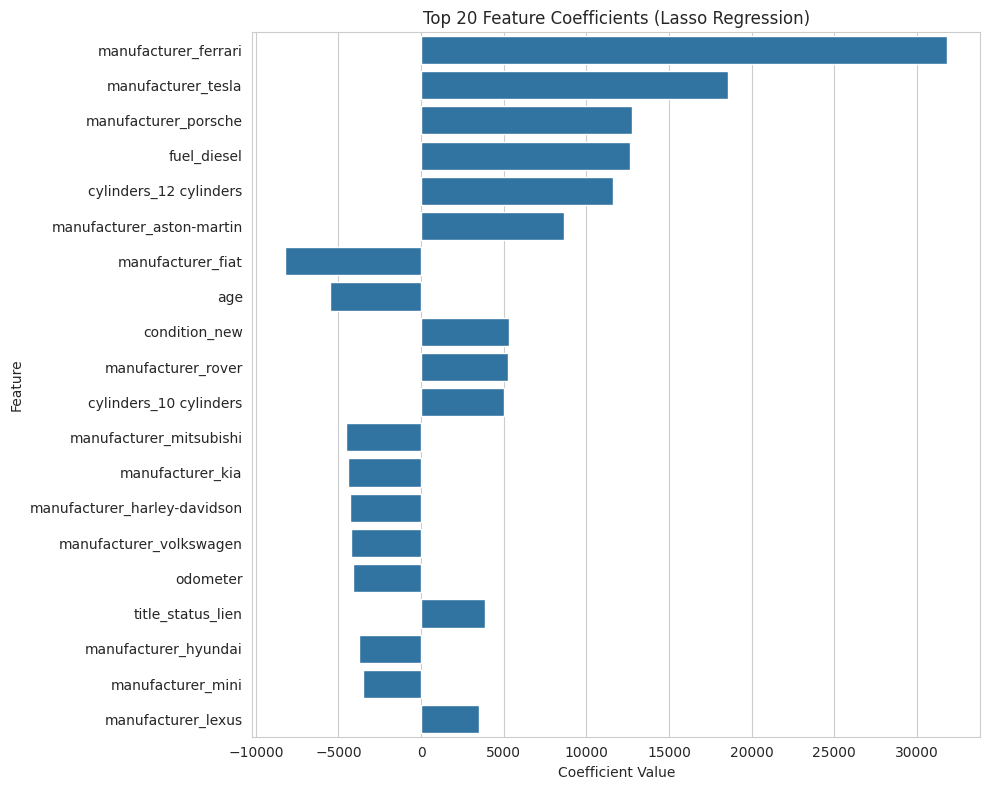

In [41]:
# Get feature names from the preprocessor
feature_names = (numerical_features +
                 list(lasso_grid.best_estimator_['preprocessor']
                      .named_transformers_['cat'].get_feature_names_out()))
coefficients = lasso_grid.best_estimator_['model'].coef_

# Create dataframe and plot top 20
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df['Abs_Coeff'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coeff', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', ax=ax)
ax.set_title('Top 20 Feature Coefficients (Lasso Regression)')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

**Feature Coefficient Interpretation:**

**Positive coefficients (increase price):**
- Luxury/performance brands dominate: Ferrari (+32K), Tesla (+18K), Porsche (+13K), Aston Martin (+8K), Lexus (+3K)
- Diesel fuel (+13K) commands a significant premium
- Higher cylinder counts (12 cylinders +12K, 10 cylinders +5K) increase price
- "New" condition (+5K) and "lien" title status (+4K) boost value

**Negative coefficients (decrease price):**
- Age (-5K) is a major price reducer — older cars are worth less
- Odometer (-3K) — higher mileage decreases value
- Budget brands reduce price: Fiat (-7K), Mitsubishi (-3K), Kia (-3K), Volkswagen (-3K), Hyundai (-2K)

## Findings & Recommendations

### Business Understanding
A used car dealership wants to understand what factors drive used car prices so they can make smarter inventory decisions. Using data from over 193,000 used car listings and regression modeling, we identified the key features that influence pricing.

### Key Findings
1. **Vehicle age and mileage are the strongest price drivers.** Newer, lower-mileage cars consistently command higher prices. Each additional year of age reduces value by approximately $5,000.
2. **Brand matters significantly.** Luxury and performance brands (Ferrari, Tesla, Porsche, Aston Martin) hold their value far better than economy brands (Fiat, Mitsubishi, Kia, Hyundai).
3. **Diesel vehicles command a premium.** Diesel fuel type adds approximately $13,000 to a vehicle's value compared to other fuel types.
4. **More cylinders = higher price.** Vehicles with 10 or 12 cylinders are priced significantly higher, reflecting demand for powerful trucks and performance vehicles.
5. **Vehicle condition impacts price.** Cars listed in "new" condition fetch a notable premium over lower condition ratings.
6. **Trucks and SUV brands hold value best.** Ram, GMC, Jeep, and Ford had the highest median prices among high-volume manufacturers.

### Recommendations for the Dealership
1. **Prioritize low-mileage, newer vehicles** — these have the highest resale value and strongest demand.
2. **Stock more trucks, SUVs, and diesel vehicles** — they command premium prices and hold value well.
3. **Invest in popular premium brands** — Tesla, Porsche, and Lexus hold value well in the used market.
4. **Avoid overinvesting in economy brands** — Fiat, Mitsubishi, Kia, and Hyundai depreciate more and sell for less.
5. **Reconditioning pays off** — improving a vehicle's condition before listing can significantly increase its selling price.

### Next Steps
- Explore non-linear models (Random Forest, XGBoost) to potentially improve the R² beyond 0.66.
- Incorporate geographic pricing data to develop region-specific inventory strategies.
- Collect additional features such as service history, accident reports, and specific trim levels for more accurate pricing.
- Build a pricing tool that uses this model to help the dealership set competitive prices for incoming inventory.